In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
import time
import h5py

In [ ]:

import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"


In [3]:
# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# print(torch.cuda.get_device_name(0))

Using device: cuda


In [ ]:

class Food101Dataset(Dataset):
    def __init__(self, json_path, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
    
        # Load and process the JSON file
        with open(json_path) as f:
            data = json.load(f)
        
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(data.keys())}
        
        for cls_name, images in data.items():
            cls_idx = self.class_to_idx[cls_name]
            for img_path in images:
                self.image_paths.append(img_path)
                self.labels.append(cls_idx)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, 'images', f"{self.image_paths[idx]}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [ ]:

root_dir = "/kaggle/input/datasets/kmader/food41"  
train_json = os.path.join(root_dir, "meta", "meta", "train.json")
test_json = os.path.join(root_dir, "meta", "meta", "test.json")

In [ ]:

train_transform = transforms.Compose([
    transforms.Resize((320, 320), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomRotation(15),  
    transforms.RandomAffine(0, translate=(0.08, 0.08), scale=(0.95, 1.05)),  
    transforms.RandomCrop(288),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  
    transforms.RandomGrayscale(p=0.05),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


train_dataset = Food101Dataset(
    json_path=train_json,
    root_dir=root_dir,
    transform=train_transform
)

val_dataset = Food101Dataset(
    json_path=test_json,
    root_dir=root_dir,
    transform=val_transform
)



batch_size = 256
  

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=True
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.class_to_idx)}")

Number of training samples: 75750
Number of validation samples: 25250
Number of classes: 101


In [ ]:

for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break

print("\n\n")
for images, labels in val_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    break

Batch shape: torch.Size([256, 3, 288, 288])
Labels shape: torch.Size([256])



Batch shape: torch.Size([256, 3, 288, 288])
Labels shape: torch.Size([256])


In [8]:
weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT 
model = torchvision.models.efficientnet_b2(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 160MB/s]


In [9]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:
summary(model.to(device),(3,288,288))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 144, 144]             864
       BatchNorm2d-2         [-1, 32, 144, 144]              64
              SiLU-3         [-1, 32, 144, 144]               0
            Conv2d-4         [-1, 32, 144, 144]             288
       BatchNorm2d-5         [-1, 32, 144, 144]              64
              SiLU-6         [-1, 32, 144, 144]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 144, 144]               0
           Conv2d-13         [-1, 16, 144, 144]             512
      BatchNorm2d-14         [-1, 16, 1

In [ ]:
# Inghetam toate straturile
for param in model.parameters():
    param.requires_grad = False

# Dezghetam ultimele 4 sub-blocuri
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Dezghetam si modificam stratul de clasificare
for param in model.classifier.parameters():
    param.requires_grad = True

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 101)

model = model.to(device)


optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)


In [12]:
model = model.to(device)

In [13]:
lossfun = nn.CrossEntropyLoss(label_smoothing=0.15)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)


In [14]:
print("Parametrii care vor fi antrenati:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Dezghetat: {name}")

Parametrii care vor fi antrenati:
Dezghetat: features.5.0.block.0.0.weight
Dezghetat: features.5.0.block.0.1.weight
Dezghetat: features.5.0.block.0.1.bias
Dezghetat: features.5.0.block.1.0.weight
Dezghetat: features.5.0.block.1.1.weight
Dezghetat: features.5.0.block.1.1.bias
Dezghetat: features.5.0.block.2.fc1.weight
Dezghetat: features.5.0.block.2.fc1.bias
Dezghetat: features.5.0.block.2.fc2.weight
Dezghetat: features.5.0.block.2.fc2.bias
Dezghetat: features.5.0.block.3.0.weight
Dezghetat: features.5.0.block.3.1.weight
Dezghetat: features.5.0.block.3.1.bias
Dezghetat: features.5.1.block.0.0.weight
Dezghetat: features.5.1.block.0.1.weight
Dezghetat: features.5.1.block.0.1.bias
Dezghetat: features.5.1.block.1.0.weight
Dezghetat: features.5.1.block.1.1.weight
Dezghetat: features.5.1.block.1.1.bias
Dezghetat: features.5.1.block.2.fc1.weight
Dezghetat: features.5.1.block.2.fc1.bias
Dezghetat: features.5.1.block.2.fc2.weight
Dezghetat: features.5.1.block.2.fc2.bias
Dezghetat: features.5.1.b

In [ ]:
def train_model(model, optimizer, lossfun, scheduler, numepochs=17):

    # Initializam costurile si acuratetea
    trainLoss = torch.zeros(numepochs)
    valLoss = torch.zeros(numepochs)
    trainAcc = torch.zeros(numepochs)
    valAcc = torch.zeros(numepochs)

    # Variabila pentru a tine minte recordul de acuratete
    best_val_acc = 0.0 
    output_dir = '/kaggle/working/'
    best_model_path = os.path.join(output_dir, 'efficientnet_b2_food101_best.pth')

    start_time = time.time()

    for epochi in range(numepochs):
        epoch_start_time = time.time()

        # Train model
        model.train()

        batch_train_loss = []
        batch_train_acc = []

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            
            yHat = model(X)
            loss = lossfun(yHat, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())

        trainLoss[epochi] = np.mean(batch_train_loss)
        trainAcc[epochi] = 100 * np.mean(batch_train_acc)


        model.eval()

        with torch.no_grad():
            
            batch_val_loss = []
            batch_val_acc = []
            
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                
                yHat = model(X)
                loss = lossfun(yHat, y)
                
                batch_val_loss.append(loss.item())
                batch_val_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())
            
            valLoss[epochi] = np.mean(batch_val_loss)
            valAcc[epochi] = 100 * np.mean(batch_val_acc)

       
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        epoch_time = (time.time() - epoch_start_time) / 60
        total_time = (time.time() - start_time) / 60  
        

        sys.stdout.write(f"\rEpoch: {epochi+1:02d}/{numepochs} | "
                         f"Train Acc: {trainAcc[epochi]:.2f}% | "
                         f"Train Loss: {trainLoss[epochi]:.4f}% | "
                         f"Val Acc: {valAcc[epochi]:.2f}% | "
                         f"Val Loss: {valLoss[epochi]:.4f}% | "
                         f"Time: {epoch_time:.1f}m | LR: {current_lr:.6f} | "
                         f"Total time: {total_time:.2f}m")
        sys.stdout.flush()

        # Salvam modelul cel mai bun
        if valAcc[epochi] > best_val_acc:
            best_val_acc = valAcc[epochi]
            
            # Creeam dictionarul cu informatiile importante
            best_model_state = {
                'epoch': epochi + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_acc': trainAcc,
                'train_loss': trainLoss,
                'best_val_acc': best_val_acc,
                'val_acc': valAcc,
                'val_loss': valLoss,
                'class_to_idx': train_dataset.class_to_idx,
                'idx_to_class': {v: k for k, v in train_dataset.class_to_idx.items()}
            }
            torch.save(best_model_state, best_model_path)
           
            print(f"\n   -> Rețea îmbunătățită! Model salvat cu acuratețe: {best_val_acc:.2f}%")
            
        torch.cuda.empty_cache()
    
    print("\nTraining completed!")
    print(f"Cel mai bun model a fost salvat la: {best_model_path} cu acuratețea de {best_val_acc:.2f}%")
    
    return trainLoss, valLoss, trainAcc, valAcc



In [16]:
trainLoss, valLoss, trainAcc, valAcc = train_model(
    model=model,
    optimizer=optimizer,
    lossfun=lossfun,
    scheduler=scheduler,
    numepochs=17
)

Epoch: 01/17 | Train Acc: 37.53% | Train Loss: 3.3801% | Val Acc: 68.24% | Val Loss: 2.1733% | Time: 45.3m | LR: 0.000100 | Total time: 45.33m
   -> Rețea îmbunătățită! Model salvat cu acuratețe: 68.24%
Epoch: 02/17 | Train Acc: 65.10% | Train Loss: 2.2441% | Val Acc: 77.77% | Val Loss: 1.8189% | Time: 33.3m | LR: 0.000099 | Total time: 78.62m
   -> Rețea îmbunătățită! Model salvat cu acuratețe: 77.77%
Epoch: 03/17 | Train Acc: 72.35% | Train Loss: 2.0021% | Val Acc: 80.94% | Val Loss: 1.7113% | Time: 33.3m | LR: 0.000098 | Total time: 111.87m
   -> Rețea îmbunătățită! Model salvat cu acuratețe: 80.94%
Epoch: 04/17 | Train Acc: 76.26% | Train Loss: 1.8776% | Val Acc: 82.86% | Val Loss: 1.6462% | Time: 33.3m | LR: 0.000096 | Total time: 145.20m
   -> Rețea îmbunătățită! Model salvat cu acuratețe: 82.86%
Epoch: 05/17 | Train Acc: 78.80% | Train Loss: 1.7917% | Val Acc: 84.09% | Val Loss: 1.6078% | Time: 33.2m | LR: 0.000093 | Total time: 178.40m
   -> Rețea îmbunătățită! Model salvat cu 

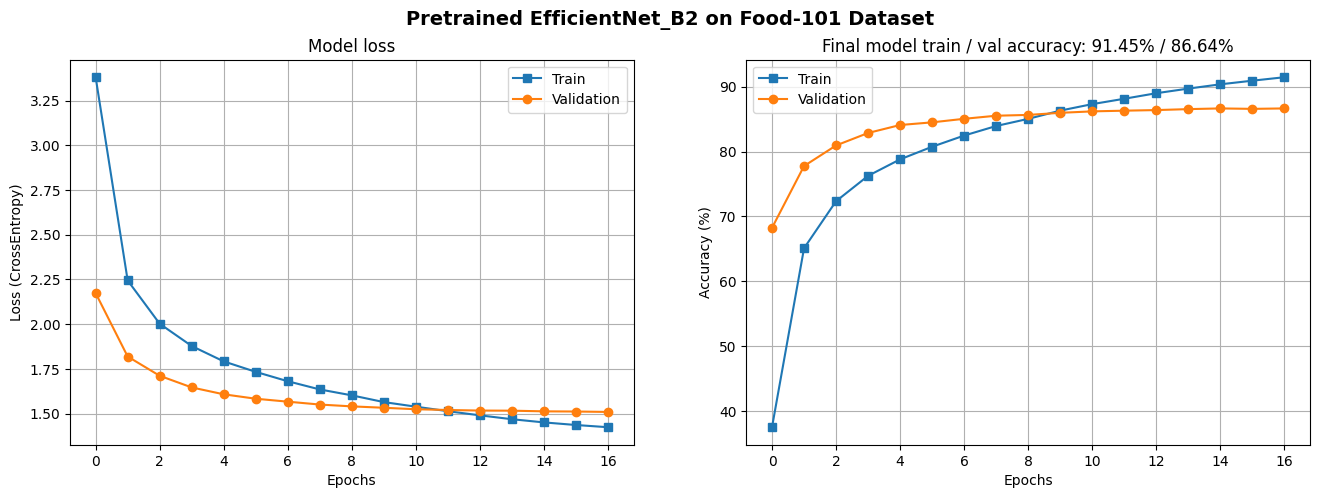

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(trainLoss, 's-', label='Train')
ax[0].plot(valLoss, 'o-', label='Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (CrossEntropy)')
ax[0].set_title('Model loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(trainAcc, 's-', label='Train')
ax[1].plot(valAcc, 'o-', label='Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model train / val accuracy: {trainAcc[-1]:.2f}% / {valAcc[-1]:.2f}%')
ax[1].legend()
ax[1].grid(True)

fig.suptitle('Pretrained EfficientNet_B2 on Food-101 Dataset', fontweight='bold', fontsize=14)
plt.show()